In [148]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_score, recall_score
from sklearn.preprocessing import StandardScaler

df = sns . load_dataset ('titanic')
print (df.shape)
print (df.head())

(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# 2.1 Część 1: Eksploracja danych

In [149]:
# 1.1
print(df.describe(include='all'))
print(df.info())

          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    2.000000   NaN   20.125000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.000000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   38.000000    1.000000    0.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              fare embarked  class  who adult_male deck  embark_town alive  \
count   8

In [150]:
# 1.2
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [151]:
# 1.3
print("Ogółem: ", df['survived'].mean())
print("Z podziałem na płeć i klase: \n",df.groupby(['sex', 'class'])['survived'].mean())


Ogółem:  0.3838383838383838
Z podziałem na płeć i klase: 
 sex     class 
female  First     0.968085
        Second    0.921053
        Third     0.500000
male    First     0.368852
        Second    0.157407
        Third     0.135447
Name: survived, dtype: float64


/tmp/ipython-input-1307947474.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print("Z podziałem na płeć i klase: \n",df.groupby(['sex', 'class'])['survived'].mean())


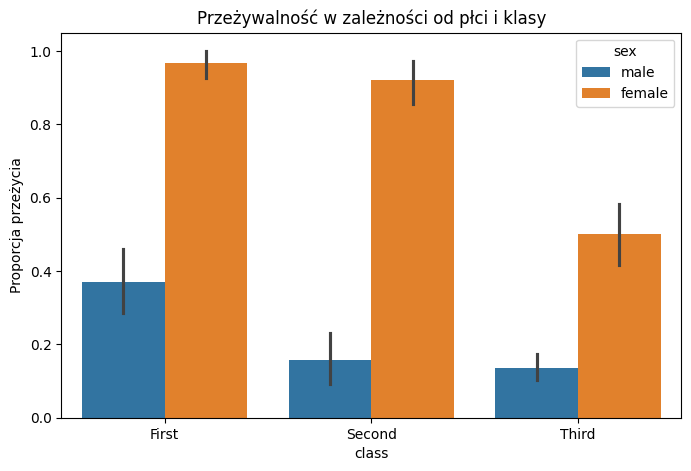

In [152]:
# 1.4
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='class', y='survived', hue='sex')
plt.title('Przeżywalność w zależności od płci i klasy')
plt.ylabel('Proporcja przeżycia')
plt.show()

# 2.2 Część 2: Przygotowanie danych

In [153]:
# 2.1
df = df.drop(columns=['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'])


In [154]:
# 2.2
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])


In [155]:
# 2.3
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df_encoded.head()
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   age         891 non-null    float64
 3   sibsp       891 non-null    int64  
 4   parch       891 non-null    int64  
 5   fare        891 non-null    float64
 6   sex_male    891 non-null    bool   
 7   embarked_Q  891 non-null    bool   
 8   embarked_S  891 non-null    bool   
 9   alone_True  891 non-null    bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 45.4 KB


In [156]:
# 2.4
y = df_encoded['survived']
X = df_encoded.drop('survived', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2.3 Część 3: Budowa modelu

In [157]:
# 3.1
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [158]:
# 3.2
coeffs = pd.DataFrame({
    'feature': X_train.columns,
    'coef': model.coef_[0]
}).sort_values(by='coef', key=abs, ascending=False)

coeffs

,feature,coef
5,sex_male,-2.489176
0,pclass,-1.050987
8,alone_True,-0.594846
2,sibsp,-0.397342
6,embarked_Q,0.359634
7,embarked_S,-0.318143
3,parch,-0.195332
1,age,-0.037334
4,fare,0.001921


* Najważniejsze zmienne
  * sex_male - współczynnik bardzo ujemny, co oznacza że bycie mężczyzną znacznie obniżało szanse na przezycie.
  * pclass - również mocno ujemny współczynnik, oznaczający że niższa klasa znacząco obniżała szanse na przeżycie.
  * alone_True - współczynnik oznaczający, że osoby samotne miały mniejsze szanse na przeżycie.

In [159]:
# 3.3
coeffs['odds_ratio'] = np.exp(coeffs['coef'])
coeffs

,feature,coef,odds_ratio
5,sex_male,-2.489176,0.082978
0,pclass,-1.050987,0.349593
8,alone_True,-0.594846,0.551647
2,sibsp,-0.397342,0.672104
6,embarked_Q,0.359634,1.432805
7,embarked_S,-0.318143,0.727499
3,parch,-0.195332,0.822561
1,age,-0.037334,0.963354
4,fare,0.001921,1.001923


Mężczyzna ma około 0.083 szans kobiety na przeżycie, czyli około 12 razy mniej.

# 2.4 Część 4: Ewaluacja modelu

In [160]:
# 4.1
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

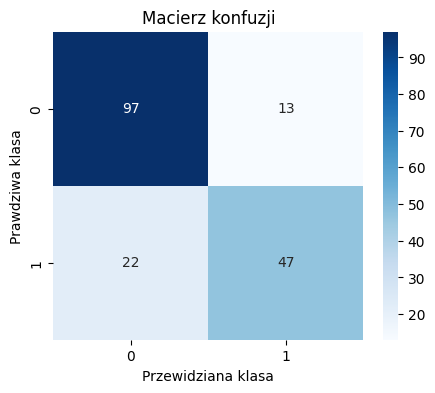

In [161]:
# 4.2
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Przewidziana klasa")
plt.ylabel("Prawdziwa klasa")
plt.title("Macierz konfuzji")
plt.show()


In [162]:
# 4.3
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP)

accuracy, precision, recall, f1, specificity

(0.8044692737430168,
 0.7833333333333333,
 0.6811594202898551,
 0.7286821705426356,
 np.float64(0.8818181818181818))

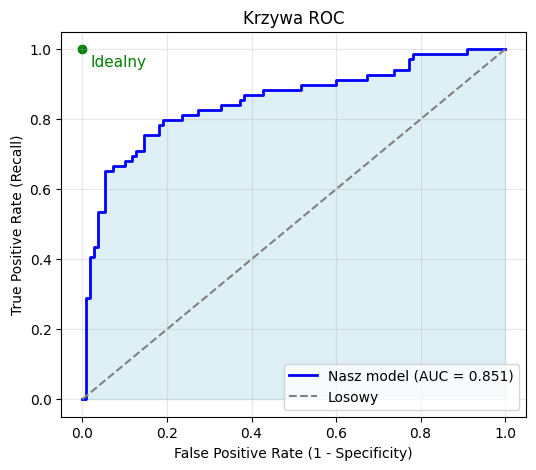

In [163]:
# 4.4
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.fill_between(fpr, tpr, color='lightblue', alpha=0.4)

plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Nasz model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Losowy')

plt.scatter(0, 1, color='green')
plt.text(0.02, 0.95, 'Idealny', color='green', fontsize=11)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")

plt.title("Krzywa ROC")
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()


* 4.5 Która metryka jest najważniejsza w tym problemie i dlaczego?
  * Według mnie najważniejsze są metryki Recall i AUC.
    * Recall jest ważny, gdyż chcemy przecież prawidłowo identyfikować osoby, które przeżyły.
    * AUC z kolei ocenia jakość modelu niezależnie od progu klasyfikacji i pozwala porównać modele w sposób obiektywny.

# 2.5 Część 5: Eksperymenty

In [164]:
# 5.1
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

results = []

for thr in thresholds:
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    prec = precision_score(y_test, y_pred_thr)
    rec = recall_score(y_test, y_pred_thr)
    results.append((thr, prec, rec))

thr_df = pd.DataFrame(results, columns=['threshold', 'precision', 'recall'])
print(thr_df)

   threshold  precision    recall
0        0.3   0.666667  0.811594
1        0.4   0.722222  0.753623
2        0.5   0.783333  0.681159
3        0.6   0.877551  0.623188
4        0.7   0.894737  0.492754


In [165]:
# 5.2
base_model = LogisticRegression(max_iter=1000)
base_model.fit(X_train, y_train)

y_pred_base = base_model.predict(X_test)

bal_model = LogisticRegression(max_iter=1000, class_weight='balanced')
bal_model.fit(X_train, y_train)

y_pred_bal = bal_model.predict(X_test)

def eval_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'specificity': TN / (TN + FP)
    }

base_metrics = eval_model(y_test, y_pred_base)
bal_metrics  = eval_model(y_test, y_pred_bal)

print("Model bazowy:", base_metrics)
print("Model balanced:", bal_metrics)

Model bazowy: {'accuracy': 0.8044692737430168, 'precision': 0.7833333333333333, 'recall': 0.6811594202898551, 'f1': 0.7286821705426356, 'specificity': np.float64(0.8818181818181818)}
Model balanced: {'accuracy': 0.7988826815642458, 'precision': 0.726027397260274, 'recall': 0.7681159420289855, 'f1': 0.7464788732394366, 'specificity': np.float64(0.8181818181818182)}


Zastosowanie class_weight='balanced' polepszyło wykrywalność osób, które przeżyły (świadczą o tym wyższy recall i F1). Wywołało to jednak pewne mankamenty, w skład których wchodzi większa liczby fałszywych alarmów oraz nieznaczny spadku dokładności.

#2.6 Część 6: Standaryzacja oraz wpływa parametru C

In [166]:
# 6.1
num_cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

In [167]:
# 6.2
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

for C in C_values:
    model = LogisticRegression(
        penalty='l2',
        C=C,
        max_iter=2000,
        solver='lbfgs'
    )
    model.fit(X_train_scaled, y_train)

    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)

    coef_sum = np.sum(np.abs(model.coef_))

    results.append((C, auc, coef_sum))

results_df = pd.DataFrame(results, columns=['C', 'AUC', 'coef_abs_sum'])
print(results_df)

         C       AUC  coef_abs_sum
0    0.001  0.768511      0.370258
1    0.010  0.815547      1.840780
2    0.100  0.848090      4.348507
3    1.000  0.851120      5.800510
4   10.000  0.850725      6.075801
5  100.000  0.850593      6.106564


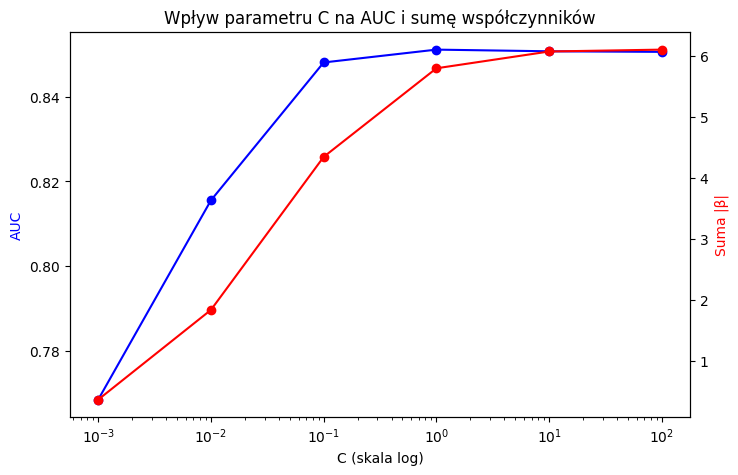

In [168]:
fig, ax1 = plt.subplots(figsize=(8,5))

ax1.set_xscale('log')
ax1.plot(results_df['C'], results_df['AUC'], marker='o', color='blue', label='AUC')
ax1.set_xlabel('C (skala log)')
ax1.set_ylabel('AUC', color='blue')

ax2 = ax1.twinx()
ax2.plot(results_df['C'], results_df['coef_abs_sum'], marker='o', color='red', label='Suma |β|')
ax2.set_ylabel('Suma |β|', color='red')

plt.title("Wpływ parametru C na AUC i sumę współczynników")
plt.show()

In [169]:
# 6.3
# L2 (ridge)
model_l2 = LogisticRegression(
    penalty='l2',
    C=0.1,
    max_iter=2000,
    solver='lbfgs'
)
model_l2.fit(X_train_scaled, y_train)

# L1 (lasso)
model_l1 = LogisticRegression(
    penalty='l1',
    C=0.1,
    max_iter=2000,
    solver='liblinear'
)
model_l1.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'L1_coef': model_l1.coef_[0],
    'L2_coef': model_l2.coef_[0]
})

print(coef_df)


      feature   L1_coef   L2_coef
0      pclass -0.754746 -0.713545
1         age -0.326772 -0.391988
2       sibsp -0.112345 -0.293641
3       parch  0.000000 -0.073613
4        fare  0.054952  0.143113
5    sex_male -1.992748 -1.821250
6  embarked_Q  0.000000  0.202668
7  embarked_S  0.000000 -0.300858
8  alone_True  0.000000 -0.407829


  * L1
    * Regularyzacja L1 wyzerowała niektóre współczynniki, co może oznaczać że nie dodają żadnej istotnej informacji do modelu:
      * parch (rodzice/dzieci)
      * embarked_Q
      * embarked_S
      * alone_True
    * Zmienne są na tyle słabe, że nie warto ich używać w przewidywaniu przeżycia.
  * L2
      * Regularyzacja L2 zachowuje wszystkie zmienne, lecz zmniejsza ich wpływ poprzez kierowanie współczynników w stronę zera.
  * W efekcie L1 tworzy oszczędniejszy i łatwiejszy w interpretacji model, za to L2 wygładza i stabilizuje parametry, przy zachowaniu pełnej informacji.